In [ ]:
# ---------------------------------------------------------------------------
# Path setup — fixes imports and data paths when notebook runs from subdir
# ---------------------------------------------------------------------------
from pathlib import Path
import sys, os

REPO_ROOT = Path().resolve().parent.parent  # notebooks/pipeline/ -> root
os.chdir(REPO_ROOT)                          # all relative paths (cache/, data/, results/, splits/) resolve from root
sys.path.insert(0, str(REPO_ROOT / "src"))   # find rise, crise, synth_gen modules

## Dataset: Labeled Faces in the Wild (LFW)

We evaluate our explainability methods using the **Labeled Faces in the Wild (LFW)** dataset. LFW is a widely used benchmark dataset for face recognition research, consisting of face photographs collected from the web under unconstrained conditions.

Key properties of LFW:

- 13,233 images
- 5,749 identitie
- Images contain variations in pose, lighting, expression, background, and occlusion

In this project we adapt LFW for **face identification**:

- **Gallery:** One image per identity  
- **Probe set:** Remaining images of each identity  
- **Impostors:** All other identities in the gallery  

Each probe image is embedded using an **ArcFace-based face recognition model (InsightFace)** and compared against the gallery embeddings to produce a ranked list of candidate identities.

This setup allows us to evaluate the faithfulness of saliency maps produced by **RISE-based explainability methods** in a realistic **1:N identification scenario**.

Dataset link:

LFW dataset:  
https://www.kaggle.com/datasets/jessicali9530/lfw-dataset

ArcFace Link:
https://github.com/deepinsight/insightface

In [12]:
import os, random, json
#Downloaded Data Root
root = "data/lfw-deepfunneled"
SEED = 123
identities = os.listdir(root)

#Verify Number of identities and images
print("Number of identities:", len(identities))

total_images = sum(len(os.listdir(os.path.join(root, id))) for id in identities)
print("Total images:", total_images)

Number of identities: 5749
Total images: 13233


In [13]:
# Drop identitites that only have one picture
def list_imgs(person):
    p = os.path.join(root, person)
    return sorted([f for f in os.listdir(p) if f.lower().endswith((".jpg",".jpeg",".png"))])

valid_ids = []
dropped = 0

for person in identities:
    if len(list_imgs(person)) >= 2:
        valid_ids.append(person)
    else:
        dropped += 1

print("Valid identities (>=2 imgs):", len(valid_ids))
print("Dropped identities:", dropped)


Valid identities (>=2 imgs): 1680
Dropped identities: 4069


In [14]:
gallery = {}   # person -> "path/to/img.jpg"
probes  = {}   # person -> ["path/to/img2.jpg", ...]

for person in sorted(valid_ids):
    imgs = list_imgs(person)

    # deterministic shuffle per identity
    rng = random.Random(hash((SEED, person)))
    rng.shuffle(imgs)

    gallery_img = imgs[0]
    probe_imgs  = imgs[1:]

    gallery[person] = os.path.join(root, person, gallery_img)
    probes[person]  = [os.path.join(root, person, f) for f in probe_imgs]

print("Gallery size:", len(gallery)) 
print("Probe images:", sum(len(v) for v in probes.values()))

Gallery size: 1680
Probe images: 7484


In [15]:
# Ensure they do not overlap
overlap = 0
for person in gallery:
    overlap += sum(1 for p in probes[person] if p == gallery[person])

print("Overlap gallery vs probes:", overlap)  # should be 0

Overlap gallery vs probes: 0


In [16]:
os.makedirs("splits", exist_ok=True)

split = {
    "dataset": "lfw-deepfunneled",
    "protocol": "closed_set_1_to_N_identification",
    "seed": SEED,
    "gallery_per_identity": 1,
    "min_images_per_identity": 2,
    "num_identities": len(gallery),
    "num_probe_images": sum(len(v) for v in probes.values()),
    "gallery": gallery,
    "probes": probes
}

with open("splits/lfw_1N_split.json", "w") as f:
    json.dump(split, f, indent=2)

print("Saved:", "splits/lfw_1N_split.json")

Saved: splits/lfw_1N_split.json


In [17]:
import cv2
import numpy as np

# path to a sample LFW image
img_path = "data/lfw-deepfunneled/Aaron_Eckhart/Aaron_Eckhart_0001.jpg"

# load image
img = cv2.imread(img_path)

# basic info
print("Image shape:", img.shape)   # (height, width, channels)
print("Height:", img.shape[0])
print("Width:", img.shape[1])
print("Channels:", img.shape[2])
print("Data type:", img.dtype)

# optional: verify color ordering
print("Color format: BGR (OpenCV default)")

Image shape: (250, 250, 3)
Height: 250
Width: 250
Channels: 3
Data type: uint8
Color format: BGR (OpenCV default)


In [18]:
import os
import numpy as np
from collections import Counter

print("root:", root)
print("Seed:", SEED)
print("Number of identities (raw):", len(identities))
print("Total images (raw):", sum(len(os.listdir(os.path.join(root, i))) for i in identities))

print("\nAfter filtering (>=2 imgs):")
print("Valid identities:", len(valid_ids))
print("Dropped identities:", dropped)

num_gallery = len(gallery)
num_probe_imgs = sum(len(v) for v in probes.values())
probe_per_id = [len(v) for v in probes.values()]

print("\nSplit stats:")
print("Gallery size (1 per identity):", num_gallery)
print("Total probe images:", num_probe_imgs)
print("Avg probes per identity:", float(np.mean(probe_per_id)))
print("Median probes per identity:", float(np.median(probe_per_id)))
print("Min/Max probes per identity:", int(np.min(probe_per_id)), int(np.max(probe_per_id)))

# quick distribution peek
cnt = Counter(probe_per_id)
top = sorted(cnt.items(), key=lambda x: (-x[1], x[0]))[:10]
print("\nMost common #probes per identity (count):")
for k, v in top:
    print(f"  {k}: {v}")

# sanity checks
overlap = sum(1 for person in gallery for p in probes[person] if p == gallery[person])
print("\nSanity checks:")
print("Overlap gallery vs probes:", overlap)
print("Any missing files in gallery?:", any(not os.path.exists(p) for p in gallery.values()))
print("Any missing files in probes?:", any(not os.path.exists(p) for person in probes for p in probes[person]))

root: data/lfw-deepfunneled
Seed: 123
Number of identities (raw): 5749
Total images (raw): 13233

After filtering (>=2 imgs):
Valid identities: 1680
Dropped identities: 4069

Split stats:
Gallery size (1 per identity): 1680
Total probe images: 7484
Avg probes per identity: 4.454761904761905
Median probes per identity: 2.0
Min/Max probes per identity: 1 529

Most common #probes per identity (count):
  1: 779
  2: 291
  3: 187
  4: 112
  5: 55
  6: 39
  7: 33
  8: 26
  10: 16
  9: 15

Sanity checks:
Overlap gallery vs probes: 0
Any missing files in gallery?: False
Any missing files in probes?: False


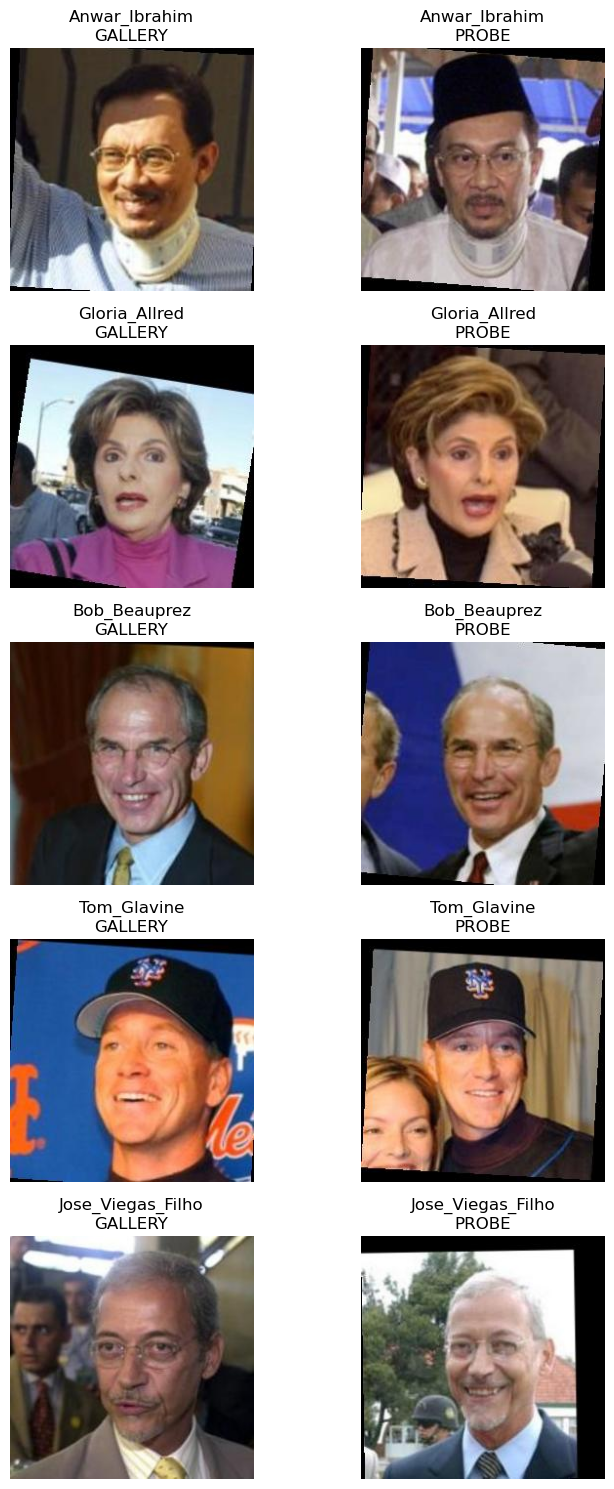

In [19]:
import random
from PIL import Image
import matplotlib.pyplot as plt

def load_rgb(path):
    return Image.open(path).convert("RGB")

rng = random.Random(SEED)  # reproducible sampling
people = rng.sample(list(gallery.keys()), k=min(5, len(gallery)))

fig, axes = plt.subplots(len(people), 2, figsize=(8, 3 * len(people)))

if len(people) == 1:
    axes = [axes]  # normalize shape for single-row case

for r, person in enumerate(people):
    g_path = gallery[person]
    p_path = rng.choice(probes[person])  # matched probe for same identity

    g_img = load_rgb(g_path)
    p_img = load_rgb(p_path)

    ax_g, ax_p = axes[r]
    ax_g.imshow(g_img)
    ax_p.imshow(p_img)

    ax_g.set_title(f"{person}\nGALLERY")
    ax_p.set_title(f"{person}\nPROBE")

    ax_g.axis("off")
    ax_p.axis("off")

plt.tight_layout()
plt.show()

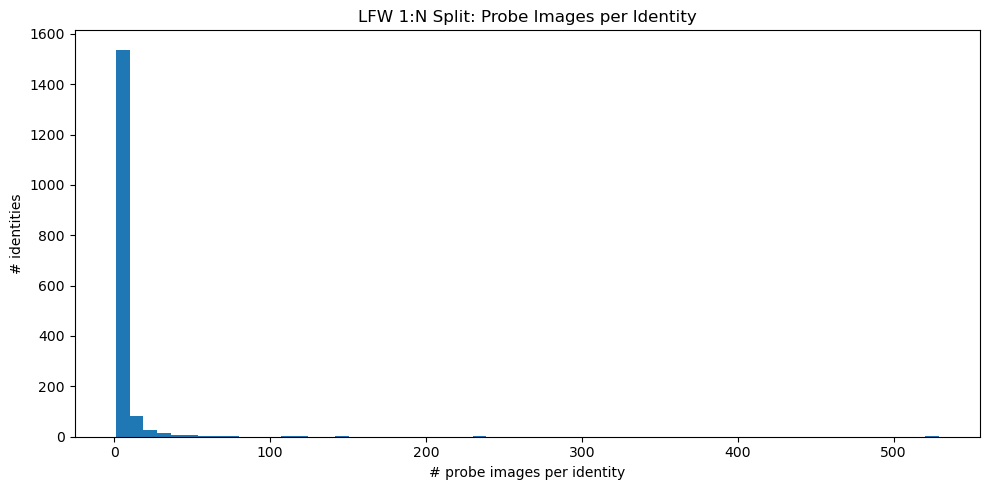

Quantiles (# probes per identity):
  0%: 1
 50%: 2
 75%: 4
 90%: 8
 95%: 15
 99%: 40
100%: 529


In [20]:
import numpy as np
import matplotlib.pyplot as plt

probe_counts = np.array([len(v) for v in probes.values()])

plt.figure(figsize=(10,5))
plt.hist(probe_counts, bins=60)
plt.title("LFW 1:N Split: Probe Images per Identity")
plt.xlabel("# probe images per identity")
plt.ylabel("# identities")
plt.tight_layout()
plt.show()

# Helpful summary stats
qs = [0, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
print("Quantiles (# probes per identity):")
for q in qs:
    print(f"{int(q*100):>3d}%: {np.quantile(probe_counts, q):.0f}")

In [21]:
# Find identity with maximum number of probe images
max_person = None
max_probes = 0

for person, p in probes.items():
    if len(p) > max_probes:
        max_probes = len(p)
        max_person = person

print("Identity with most probe images:", max_person)
print("Number of probe images:", max_probes)
print("Gallery image:", gallery[max_person])
print("Total images:", max_probes + 1)

Identity with most probe images: George_W_Bush
Number of probe images: 529
Gallery image: data/lfw-deepfunneled/George_W_Bush/George_W_Bush_0337.jpg
Total images: 530
